In [1]:
import pandas as pd 
 
df = pd.read_csv('loancleaned.csv')

df


,Unnamed: 0,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,...,EMI_Income_Ratio,Log_ApplicantIncome,Log_CoapplicantIncome,Log_LoanAmount,Log_TotalIncome,Has_Coapplicant,HighLoan,Area_Rural,Area_Semiurban,Area_Urban
0,0,1,0,0,1,0,5849.0,0.0,128.0,360.0,...,0.060789,8.674197,0.000000,4.859812,8.674197,0,0,0,0,1
1,1,1,1,1,1,0,4583.0,1508.0,128.0,360.0,...,0.058374,8.430327,7.319202,4.859812,8.714732,1,0,1,0,0
2,2,1,1,0,1,1,3000.0,0.0,66.0,360.0,...,0.061111,8.006701,0.000000,4.204693,8.006701,0,0,0,0,1
3,3,1,1,0,0,0,2583.0,2358.0,120.0,360.0,...,0.067463,7.857094,7.765993,4.795791,8.505525,1,0,0,0,1
4,4,1,0,0,1,0,6000.0,0.0,141.0,360.0,...,0.065278,8.699681,0.000000,4.955827,8.699681,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,609,0,0,0,1,0,2900.0,0.0,71.0,360.0,...,0.068008,7.972811,0.000000,4.276666,7.972811,0,0,1,0,0
610,610,1,1,3,1,0,4106.0,0.0,40.0,180.0,...,0.054121,8.320448,0.000000,3.713572,8.320448,0,0,1,0,0
611,611,1,1,1,1,0,8072.0,240.0,253.0,360.0,...,0.084550,8.996280,5.484797,5.537334,9.025576,1,1,0,0,1
612,612,1,1,2,1,0,7583.0,0.0,187.0,360.0,...,0.068501,8.933796,0.000000,5.236442,8.933796,0,1,0,0,1


In [2]:
# Séparer X (features) et y (cible)
X = df.drop('Loan_Status', axis=1)  # Toutes les colonnes sauf Loan_Status
y = df['Loan_Status']               # Uniquement la colonne cible

print(f"Features (X) : {X.shape}")
print(f"Cible (y) : {y.shape}")

Features (X) : (614, 22)
Cible (y) : (614,)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")


Train : (491, 22) | Test : (123, 22)


=== Régression Logistique ===
Accuracy : 0.7805
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



C:\Users\Yacin\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


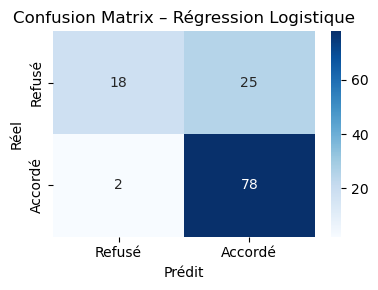

In [4]:
# ── Régression Logistique ──────────────────────────────────────────────────
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Régression Logistique ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Refusé', 'Accordé'], yticklabels=['Refusé', 'Accordé'], ax=ax)
ax.set_title("Confusion Matrix – Régression Logistique")
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
plt.tight_layout(); plt.show()


=== Random Forest ===
Accuracy : 0.7805
              precision    recall  f1-score   support

           0       0.86      0.44      0.58        43
           1       0.76      0.96      0.85        80

    accuracy                           0.78       123
   macro avg       0.81      0.70      0.72       123
weighted avg       0.80      0.78      0.76       123



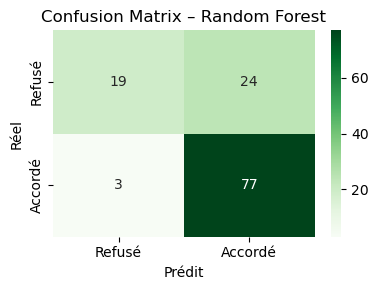

In [5]:
# ── Random Forest ──────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf))

# Matrice de confusion
fig, ax = plt.subplots(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens',
            xticklabels=['Refusé', 'Accordé'], yticklabels=['Refusé', 'Accordé'], ax=ax)
ax.set_title("Confusion Matrix – Random Forest")
ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
plt.tight_layout(); plt.show()


               Modèle  Accuracy
Régression Logistique  0.780488
        Random Forest  0.780488


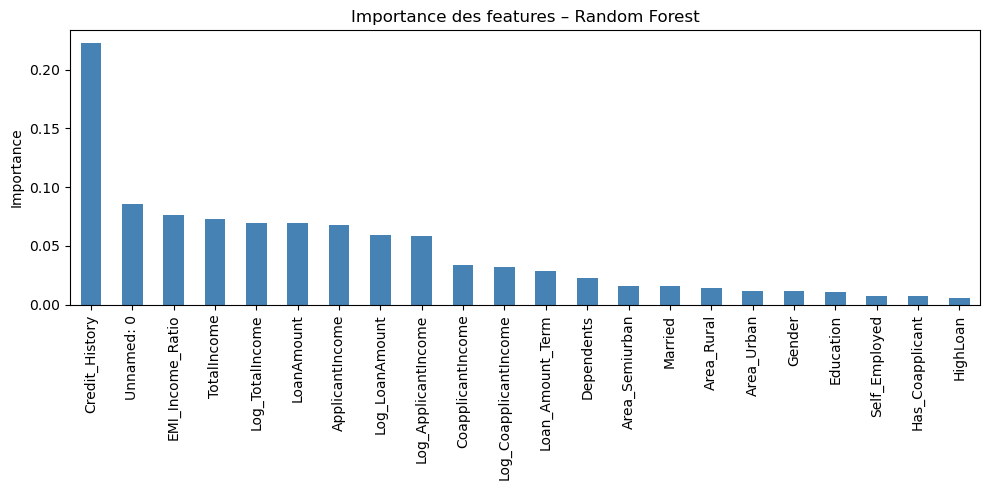

In [6]:
# ── Comparaison des deux modèles ───────────────────────────────────────────
resultats = pd.DataFrame({
    'Modèle': ['Régression Logistique', 'Random Forest'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_rf)]
})

print(resultats.to_string(index=False))

# Importance des features (Random Forest)
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title("Importance des features – Random Forest")
ax.set_ylabel("Importance")
plt.tight_layout(); plt.show()


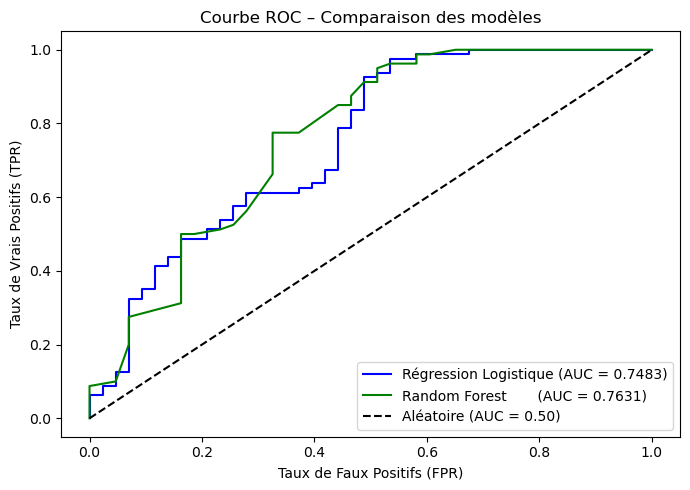

AUC – Régression Logistique : 0.7483
AUC – Random Forest         : 0.7631


In [7]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probabilités pour le calcul ROC
y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Courbes ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_rf = roc_auc_score(y_test, y_prob_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, label=f"Régression Logistique (AUC = {auc_lr:.4f})", color='blue')
ax.plot(fpr_rf, tpr_rf, label=f"Random Forest       (AUC = {auc_rf:.4f})", color='green')
ax.plot([0, 1], [0, 1], 'k--', label="Aléatoire (AUC = 0.50)")
ax.set_xlabel("Taux de Faux Positifs (FPR)")
ax.set_ylabel("Taux de Vrais Positifs (TPR)")
ax.set_title("Courbe ROC – Comparaison des modèles")
ax.legend()
plt.tight_layout(); plt.show()

print(f"AUC – Régression Logistique : {auc_lr:.4f}")
print(f"AUC – Random Forest         : {auc_rf:.4f}")


In [8]:
import joblib
# Sauvegarder les modèles
joblib.dump(lr, 'modele_logistic_regression.pkl')

['modele_logistic_regression.pkl']